# Aurora — Week 1: GFP data exploration

Goal for this notebook: load the GFP fluorescence landscape, understand its shape,
and *see* the train/test distribution shift that makes this a real generalization
problem. Everything reusable lives in `src/aurora/data.py`; this notebook just calls it.

In [1]:
from aurora.data import load_gfp, train_test
import matplotlib.pyplot as plt

df = load_gfp()          # downloads from HuggingFace once, then caches to data/processed/
df.head()

Matplotlib is building the font cache; this may take a moment.


,sequence,log_fluorescence,split,num_mutations
0,SKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFI...,3.823701,train,6.0
1,SKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFI...,3.752084,train,6.0
2,SKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGRLTLKFI...,3.753380,train,6.0
3,SKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDANYGKLTLKFI...,3.752505,train,5.0
4,SKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFI...,3.576366,train,7.0


In [2]:
# Basic shape
print(f"{len(df):,} variants total")
print(df["split"].value_counts(), "\n")
print(df[["log_fluorescence", "num_mutations"]].describe())

54,025 variants total
split
test     27217
train    21446
valid     5362
Name: count, dtype: int64 

       log_fluorescence  num_mutations
count      54025.000000   51715.000000
mean           2.626653       7.759141
std            1.060261       1.855348
min            1.283419       0.000000
25%            1.414430       6.000000
50%            3.259355       7.000000
75%            3.608273       9.000000
max            4.123109      18.000000


## 1. What does the brightness label look like?

`log_fluorescence` is the target — higher means brighter. Notice it's bimodal:
a bright cluster and a dark cluster. That bimodality is the whole game.

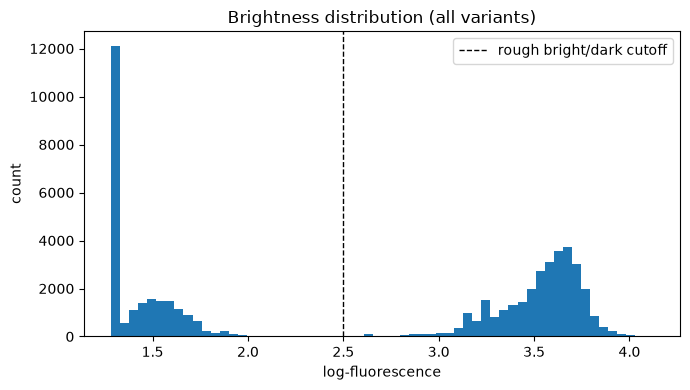

In [3]:
plt.figure(figsize=(7, 4))
plt.hist(df["log_fluorescence"], bins=60)
plt.axvline(2.5, color="k", ls="--", lw=1, label="rough bright/dark cutoff")
plt.xlabel("log-fluorescence"); plt.ylabel("count"); plt.legend()
plt.title("Brightness distribution (all variants)"); plt.tight_layout(); plt.show()

## 2. Brightness vs. mutational load

More mutations away from wild-type -> more likely to be dark. This is the fitness
landscape collapsing as you move away from the functional neighborhood.

In [4]:
sub = df.dropna(subset=["num_mutations"])
groups = [sub.loc[sub["num_mutations"] == k, "log_fluorescence"] for k in sorted(sub["num_mutations"].unique())]
plt.figure(figsize=(8, 4))
plt.boxplot(groups, labels=[str(k) for k in sorted(sub["num_mutations"].unique())], showfliers=False)
plt.xlabel("number of mutations from wild-type"); plt.ylabel("log-fluorescence")
plt.title("Brightness decays with mutational distance"); plt.tight_layout(); plt.show()

TypeError: boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?

<Figure size 800x400 with 0 Axes>

## 3. The train/test shift (the important plot)

TAPE splits by edit distance: **train = <=3 mutations, test = >=4 mutations.**
So the model learns on a mostly-bright local neighborhood and is tested on a
mostly-dark, farther region it never saw. Overlaying the two label distributions
makes the shift obvious — this is exactly what your oracle has to survive, and
later, what your optimizer will try to exploit.

In [ ]:
train_df, test_df = train_test(df)
print(f"train: {len(train_df):,}   test: {len(test_df):,}")
for name, part in [("train (<=3 mut)", train_df), ("test (>=4 mut)", test_df)]:
    frac_bright = (part["log_fluorescence"] > 2.5).mean()
    print(f"{name:>16}: {frac_bright:5.1%} bright")

plt.figure(figsize=(7, 4))
plt.hist(train_df["log_fluorescence"], bins=60, alpha=0.6, density=True, label="train (<=3 mut)")
plt.hist(test_df["log_fluorescence"], bins=60, alpha=0.6, density=True, label="test (>=4 mut)")
plt.xlabel("log-fluorescence"); plt.ylabel("density"); plt.legend()
plt.title("Train vs test: a real distribution shift"); plt.tight_layout(); plt.show()

## 4. Sanity checks

Sequences should all be ~the same length (point mutants of one protein), and there
should be no missing labels. Quick checks now save confusing bugs later.

In [ ]:
lengths = df["sequence"].str.len()
print("sequence length: min", lengths.min(), "max", lengths.max())
print("unique lengths:", sorted(lengths.unique())[:10])
print("missing labels:", df["log_fluorescence"].isna().sum())
print("duplicate sequences:", df["sequence"].duplicated().sum())

## Takeaways

- The landscape is **bimodal** (bright vs dark) and **collapses with mutations**.
- The **train/test split is an extrapolation test**, not a random split — train is
  mostly bright, test is mostly dark. A model that just predicts "bright" scores
  well on train and falls apart on test.
- Next week (oracle v1): frozen ESM-2 embeddings + a small regression head, and
  measure **test-set Spearman** honestly against this shift.